In [1]:
# Importing libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data cleanup
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
df_exploded = df.explode('job_skills')

<Axes: xlabel='job_skills'>

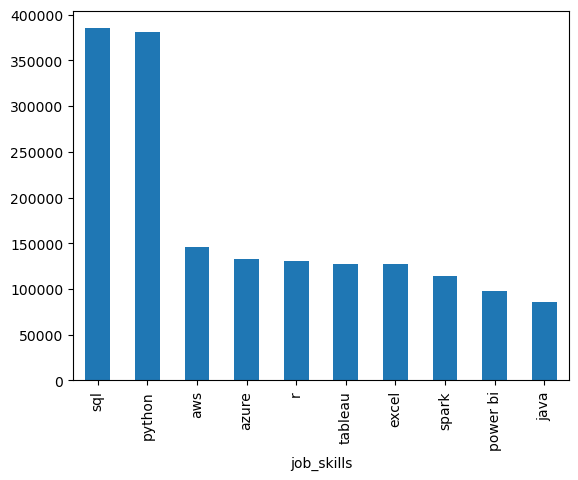

In [6]:
df_exploded['job_skills'].value_counts().head(10).plot(kind= 'bar')

In [12]:
skills_count = df_exploded.groupby(['job_title_short', 'job_skills']).size()

In [13]:
df_skill_count = skills_count.reset_index(name='skills_count')

In [14]:
df_skill_count = df_skill_count.sort_values(by= 'skills_count', ascending= False)

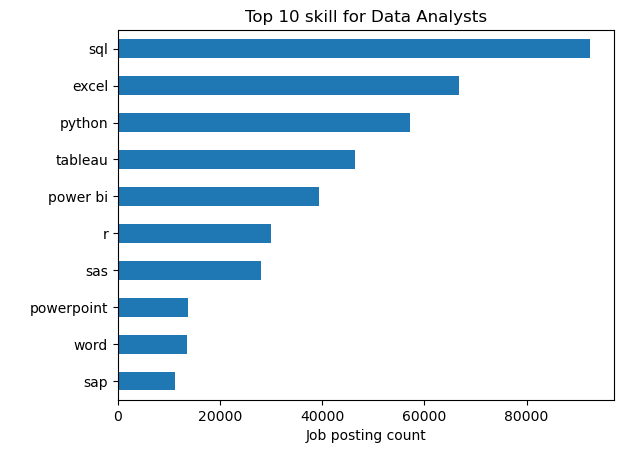

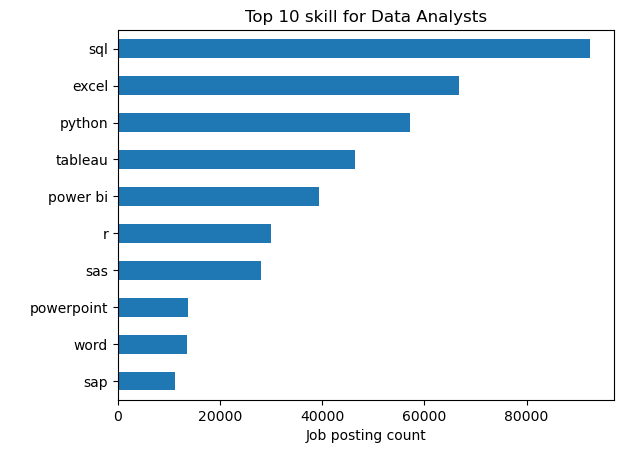

In [21]:
job_title = 'Data Analyst'
top_skill = 10
df_skill_final = df_skill_count[df_skill_count['job_title_short'] == job_title].head(top_skill)
df_skill_final.plot(kind= 'barh', x= 'job_skills', y= 'skills_count')
plt.gca().invert_yaxis()
plt.title(f'Top {top_skill} skill for {job_title}s')
plt.xlabel('Job posting count')
plt.ylabel(' ')
plt.legend().set_visible(False)
plt.show(0)